In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
sns.set_theme(style="darkgrid")

#DATA PREPARATION AND MERGING
def load_and_merge_data(covid_path, mobility_path):
    print("Loading and synchronizing datasets...")
    covid_df = pd.read_csv(covid_path)
    mob_df = pd.read_csv(mobility_path)
    
    covid_df = covid_df.rename(columns=lambda x: x.strip().lower())
    mob_df = mob_df.rename(columns=lambda x: x.strip().lower())
    
    date_col_covid = 'date'
    state_col_covid = 'province_state' if 'province_state' in covid_df.columns else 'state'
    date_col_mob = 'date'
    state_col_mob = 'province_state' if 'province_state' in mob_df.columns else 'sub_region_1'
    
    covid_df[date_col_covid] = pd.to_datetime(covid_df[date_col_covid], format='mixed', dayfirst=True)
    mob_df[date_col_mob] = pd.to_datetime(mob_df[date_col_mob], format='mixed', dayfirst=True)
    
    covid_df[state_col_covid] = covid_df[state_col_covid].astype(str).str.strip().str.title()
    mob_df[state_col_mob] = mob_df[state_col_mob].astype(str).str.strip().str.title()
    
    target_covid_cols = [date_col_covid, state_col_covid, 'latitude', 'longitude', 'cases_7day_avg']
    covid_df = covid_df[[c for c in target_covid_cols if c in covid_df.columns]]
    
    merged_df = pd.merge(
        covid_df, mob_df, 
        left_on=[date_col_covid, state_col_covid], 
        right_on=[date_col_mob, state_col_mob], 
        how='inner'
    )
    
    merged_df = merged_df.rename(columns={
        date_col_covid: 'Date', 
        state_col_covid: 'State',
        'cases_7day_avg': 'Cases',
        'workplaces_percent_change_from_baseline': 'Mobility_Work'
    })
    
    if 'mobility_work' in merged_df.columns:
        merged_df = merged_df.rename(columns={'mobility_work': 'Mobility_Work'})
    
    merged_df = merged_df.dropna(subset=['Cases', 'Mobility_Work']).sort_values(by=['State', 'Date'])
    return merged_df

#GRAPH CONSTRUCTION
def construct_empirical_graph(df):
    print("Constructing Spatio-Temporal Graph...")
    states = sorted(df['State'].unique())
    num_nodes = len(states)
    
    coords = []
    for state in states:
        state_data = df[df['State'] == state].iloc[0]
        coords.append([state_data.get('latitude', 20.0), state_data.get('longitude', 78.0)])
    coords = np.array(coords)
    
    A_emp = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            if i != j:
                dist = np.linalg.norm(coords[i] - coords[j])
                A_emp[i, j] = np.exp(-dist / 5.0) 
                
    A_emp[A_emp < 0.1] = 0
    return torch.FloatTensor(A_emp), states

#GRAPH NEURAL SDE ARCHITECTURE
class GraphConv(nn.Module):
    def __init__(self, in_feat, out_feat):
        super(GraphConv, self).__init__()
        self.linear = nn.Linear(in_feat, out_feat)
        
    def forward(self, x, A):
        A_hat = A + torch.eye(A.shape[0], device=A.device)
        degree = torch.sum(A_hat, dim=1)
        D_inv_sqrt = torch.diag(1.0 / torch.sqrt(torch.clamp(degree, min=1e-8)))
        norm_A = torch.mm(torch.mm(D_inv_sqrt, A_hat), D_inv_sqrt)
        return torch.mm(norm_A, self.linear(x))

class EnhancedGraphNeuralSDE(nn.Module):
    def __init__(self, num_features, hidden_dim=64):
        super(EnhancedGraphNeuralSDE, self).__init__()
        #Drift Network
        self.drift_gcn1 = GraphConv(num_features, hidden_dim)
        self.drift_gcn2 = GraphConv(hidden_dim, hidden_dim)
        self.drift_fc = nn.Linear(hidden_dim, num_features)
        
        #Diffusion Network
        self.diff_gcn1 = GraphConv(num_features, hidden_dim)
        self.diff_fc = nn.Linear(hidden_dim, num_features)
        
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, x0, A, steps=7, dt=1.0):
        H = x0
        for _ in range(steps):
            #Drift 
            drift_h = self.leaky_relu(self.drift_gcn1(H, A))
            drift_h = self.dropout(drift_h)
            drift_h = self.leaky_relu(self.drift_gcn2(drift_h, A))
            drift = self.drift_fc(drift_h)
            
            #Diffusion
            diff_h = self.leaky_relu(self.diff_gcn1(H, A))
            diffusion = torch.sigmoid(self.diff_fc(diff_h)) * 0.05 
            
            #Brownian increment
            dW = torch.randn_like(H) * np.sqrt(dt)
            
            #Euler-Maruyama step
            H = H + drift * dt + diffusion * dW
        return H

#DATA TENSORS & PLOTTING FUNCTIONS
def prepare_tensors(df, states):
    dates = sorted(df['Date'].unique())
    seq_length = len(dates)
    num_nodes = len(states)
    
    X_raw = np.zeros((seq_length, num_nodes, 2))
    state_to_idx = {state: i for i, state in enumerate(states)}
    
    for t, date in enumerate(dates):
        date_data = df[df['Date'] == date]
        for _, row in date_data.iterrows():
            idx = state_to_idx[row['State']]
            X_raw[t, idx, 0] = row['Cases']
            X_raw[t, idx, 1] = row['Mobility_Work']
            
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_raw.reshape(-1, 2)).reshape(seq_length, num_nodes, 2)
    return X_scaled, scaler, seq_length, dates

def plot_visuals(loss_history, true_cases, pred_cases, state_name="Average Node"):
    print("\nGenerating Visualizations...")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    #Training Loss
    axes[0].plot(loss_history, color='red', linewidth=2)
    axes[0].set_title('Graph Neural SDE Training Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Mean Squared Error', fontsize=12)
    
    #True vs Predicted (Flattened across test set)
    #Sampling a subset (e.g., 50 days) for clean visualization
    sample_len = min(50, len(true_cases))
    axes[1].plot(true_cases[:sample_len], label='True Cases (7-day forecast)', color='blue', marker='o')
    axes[1].plot(pred_cases[:sample_len], label='Predicted Cases', color='orange', linestyle='dashed', marker='x')
    axes[1].set_title(f'7-Day Forecast Accuracy Sample', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Days (Test Set Sample)', fontsize=12)
    axes[1].set_ylabel('COVID-19 Cases', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig("ARTPARK_Model_Results.png", dpi=300)
    print("Visualizations saved as 'ARTPARK_Model_Results.png'")
    plt.show()

#TRAINING PIPELINE
def train_and_evaluate(X_scaled, A_tensor, scaler, seq_length):
    num_features = X_scaled.shape[2]
    # Upped hidden dimension for better feature extraction
    model = EnhancedGraphNeuralSDE(num_features=num_features, hidden_dim=64)
    optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=20, factor=0.5)
    criterion = nn.MSELoss()
    
    forecast_horizon = 7 
    split_idx = int(seq_length * 0.8) 
    
    print("\nTraining Enhanced Graph Neural SDE...")
    epochs = 250
    model.train()
    loss_history = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for t in range(split_idx - forecast_horizon):
            optimizer.zero_grad()
            x_t = torch.FloatTensor(X_scaled[t])
            y_true = torch.FloatTensor(X_scaled[t + forecast_horizon])
            
            y_pred = model(x_t, A_tensor, steps=forecast_horizon)
            
            loss = criterion(y_pred, y_true)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / (split_idx - forecast_horizon)
        loss_history.append(avg_loss)
        scheduler.step(avg_loss) # Step scheduler
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Avg MSE Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
            
    print("\nEvaluating Out-of-Sample Predictions...")
    model.eval()
    all_preds = []
    all_trues = []
    
    with torch.no_grad():
        for t in range(split_idx, seq_length - forecast_horizon):
            x_t = torch.FloatTensor(X_scaled[t])
            y_true = X_scaled[t + forecast_horizon]
            
            y_pred = model(x_t, A_tensor, steps=forecast_horizon)
            
            pred_unscaled = scaler.inverse_transform(y_pred.numpy().reshape(-1, 2))
            true_unscaled = scaler.inverse_transform(y_true.reshape(-1, 2))
            
            all_preds.append(np.sum(pred_unscaled[0, 0])) 
            all_trues.append(np.sum(true_unscaled[0, 0]))
            
    rmse = np.sqrt(mean_squared_error(all_trues, all_preds))
    mae = mean_absolute_error(all_trues, all_preds)
    
    print("="*40)
    print("FINAL 7-DAY FORECAST PERFORMANCE")
    print("="*40)
    print(f"RMSE: {rmse:.2f} cases")
    print(f"MAE:  {mae:.2f} cases")
    print("="*40)
    
    # Trigger plotting
    plot_visuals(loss_history, all_trues, all_preds)

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
C:\Users\prane\AppData\Local\Temp\ipykernel_34068\2348889777.py:2: SyntaxWarning: invalid escape sequence '\I'
  COVID_FILE = ".\India_COVID_Cleaned.csv"
C:\Users\prane\AppData\Local\Temp\ipykernel_34068\2348889777.py:3: SyntaxWarning: invalid escape sequence '\I'
  MOBILITY_FILE = ".\India_Mobility_Cleaned.csv"


Loading and synchronizing datasets...
Constructing Spatio-Temporal Graph...

Training Enhanced Graph Neural SDE...
Epoch 50/250 | Avg MSE Loss: 0.000870 | LR: 0.001250
Epoch 100/250 | Avg MSE Loss: 0.000745 | LR: 0.001250
Epoch 150/250 | Avg MSE Loss: 0.000688 | LR: 0.000625
Epoch 200/250 | Avg MSE Loss: 0.000726 | LR: 0.000313
Epoch 250/250 | Avg MSE Loss: 0.000793 | LR: 0.000078

Evaluating Out-of-Sample Predictions...
FINAL 7-DAY FORECAST PERFORMANCE
RMSE: 171.72 cases
MAE:  130.13 cases

Generating Visualizations...
Visualizations saved as 'ARTPARK_Model_Results.png'


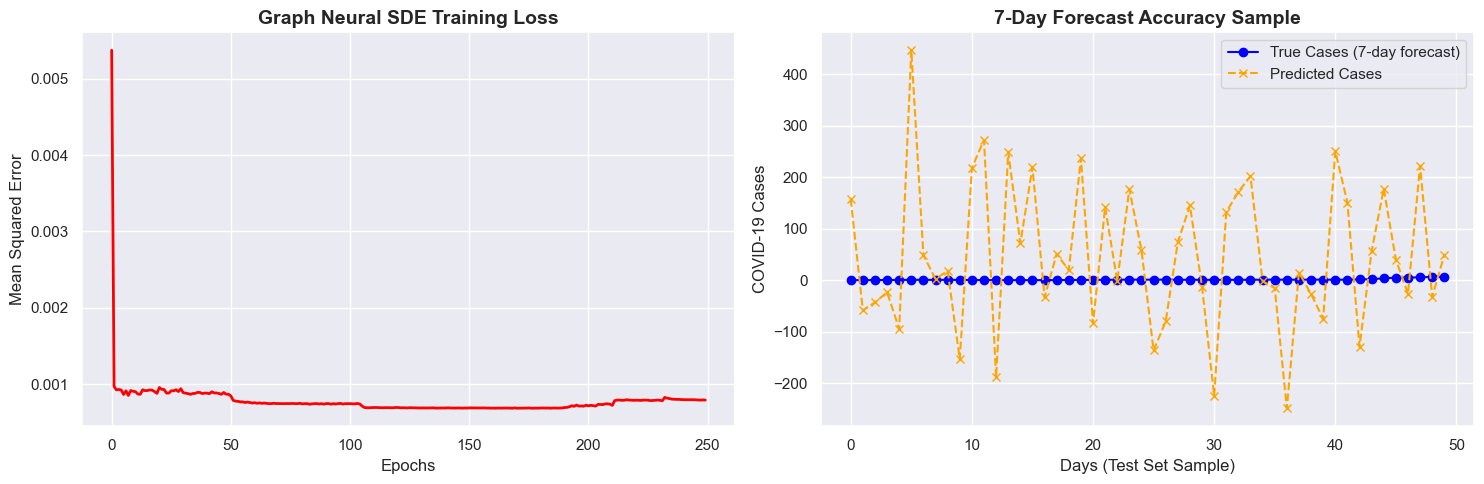


Analysis Complete.


In [10]:
if __name__ == "__main__":
    COVID_FILE = ".\India_COVID_Cleaned.csv"
    MOBILITY_FILE = ".\India_Mobility_Cleaned.csv"
    
    try:
        df_merged = load_and_merge_data(COVID_FILE, MOBILITY_FILE)
        A_tensor, states = construct_empirical_graph(df_merged)
        
        X_scaled, scaler, seq_length, dates = prepare_tensors(df_merged, states)
        train_and_evaluate(X_scaled, A_tensor, scaler, seq_length)
        print("\nAnalysis Complete.")
        
    except FileNotFoundError:
        print(f"Error: Could not find {COVID_FILE} or {MOBILITY_FILE}.")